<a href="https://colab.research.google.com/github/Fatema5007/Deep-Learning-Foundations/blob/main/Task_2_ANN_Housing_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Load California Housing Dataset
california = fetch_california_housing()
X, y = california.data, california.target

# Split into 80% Train and 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. PyTorch Custom Dataset Class
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Regression dimension matching

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create DataLoaders
train_loader = DataLoader(HousingDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(HousingDataset(X_test, y_test), batch_size=64, shuffle=False)

print("California Housing Data Pipeline Ready!")
print(f"Features dimension: {X_train.shape[1]}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

California Housing Data Pipeline Ready!
Features dimension: 8
Train samples: 16512, Test samples: 4128


In [2]:
class HousingANN(nn.Module):
    def __init__(self, input_dim, activation_name="relu"):
        super(HousingANN, self).__init__()

        # Select Activation Function based on requirement
        if activation_name == "relu":
            self.act = nn.ReLU()
        elif activation_name == "leaky_relu":
            self.act = nn.LeakyReLU(negative_slope=0.01)
        elif activation_name == "tanh":
            self.act = nn.Tanh()

        # Hidden Layers
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)

        # Output Layer (Linear function for Regression tasks)
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        return self.out(x)

print("Flexible Housing ANN Architecture Defined Successfully!")

Flexible Housing ANN Architecture Defined Successfully!


In [3]:
def train_and_evaluate(activation_name, optimizer_name, epochs=40):
    torch.manual_seed(42) # Strict reproducibility

    model = HousingANN(input_dim=8, activation_name=activation_name)
    criterion = nn.MSELoss() # Mean Squared Error Loss for regression

    # Select Optimizer among 3 choices requested by sir
    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=0.005)
    elif optimizer_name == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=0.005)

    loss_history = []

    # Training Loop
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))

    # Evaluation Loop
    model.eval()
    test_mse = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_mse += loss.item() * batch_X.size(0)

    # Final Root Mean Squared Error (RMSE) Calculation
    total_test_mse = test_mse / len(test_loader.dataset)
    final_rmse = np.sqrt(total_test_mse)

    return loss_history, final_rmse

print("Training & Regression Evaluation Engine Setup Done!")

Training & Regression Evaluation Engine Setup Done!


1. Running Config 1: ReLU + Adam...
2. Running Config 2: LeakyReLU + SGD...
3. Running Config 3: Tanh + RMSprop...

Configuration Set         | Final Test RMSE
ReLU + Adam               | 0.5250         
LeakyReLU + SGD           | 0.5665         
Tanh + RMSprop            | 0.5204         


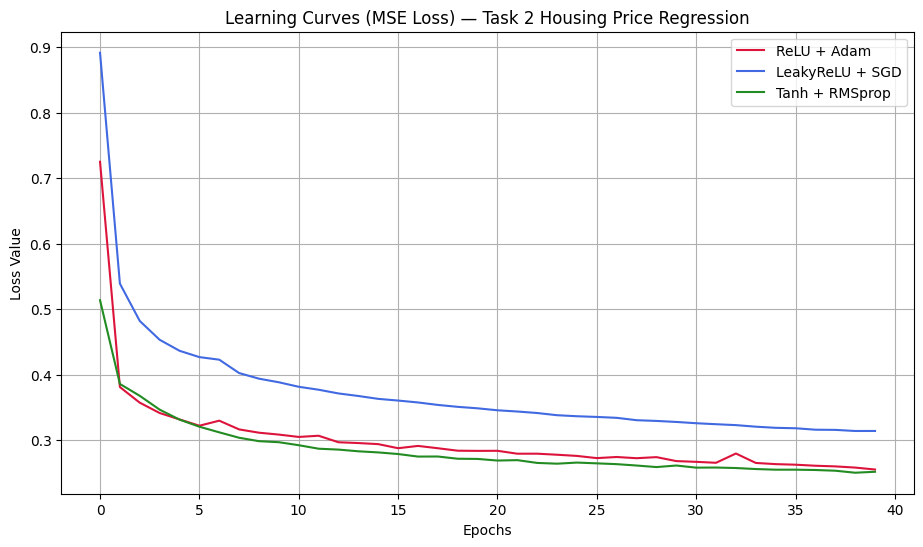

In [4]:
# Run 3 Different Configurations as requested in task
print("1. Running Config 1: ReLU + Adam...")
loss_c1, rmse_c1 = train_and_evaluate("relu", "adam")

print("2. Running Config 2: LeakyReLU + SGD...")
loss_c2, rmse_c2 = train_and_evaluate("leaky_relu", "sgd")

print("3. Running Config 3: Tanh + RMSprop...")
loss_c3, rmse_c3 = train_and_evaluate("tanh", "rmsprop")

# Print Final Comparison Report Table
print("\n" + "="*50)
print(f"{'Configuration Set':<25} | {'Final Test RMSE':<15}")
print("="*50)
print(f"{'ReLU + Adam':<25} | {rmse_c1:<15.4f}")
print(f"{'LeakyReLU + SGD':<25} | {rmse_c2:<15.4f}")
print(f"{'Tanh + RMSprop':<25} | {rmse_c3:<15.4f}")
print("="*50)

# Plot Learning Curves Comparison
plt.figure(figsize=(11, 6))
plt.plot(loss_c1, label='ReLU + Adam', color='crimson')
plt.plot(loss_c2, label='LeakyReLU + SGD', color='royalblue')
plt.plot(loss_c3, label='Tanh + RMSprop', color='forestgreen')
plt.title('Learning Curves (MSE Loss) — Task 2 Housing Price Regression')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.show()